## Meta-tokenization

### Text corpura

In [12]:
import os
import json

json_dir = "../../dataset/reason_seg/ReasonSeg/test"

texts = []

for filename in os.listdir(json_dir):
    if filename.endswith(".json"):
        file_path = os.path.join(json_dir, filename)
        with open(file_path, 'r') as f:
            data = json.load(f)
            if "text" in data:
                texts.extend(data["text"])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 3408


In [13]:
directory = '../../dataset/llm-seg40k/validation.json'
text = "In this space that is conducive to learning, what can be used to write on the whiteboard?"

with open(directory, 'r') as f:
    json_file = json.load(f)

for image, infos in json_file.items():
    questions = [info['question'] for info in infos['qa_pairs']]
    for text in questions:
        texts.append(text)

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 7313


In [14]:
import pickle

directory = '../../dataset/refer_seg/refcocog/refs(google).p'
with open(directory, 'rb') as f:
    data = pickle.load(f)

for item in data:
    for sentence in item['sentences']:
        texts.append(sentence['sent'])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 102323


### Load tokenizers

In [4]:
from transformers import AutoTokenizer

lisa_tokenizer = AutoTokenizer.from_pretrained(
    "xinlai/LISA-13B-llama2-v1",
    use_fast=False,
    add_eos_token=True
)
lisa_tokenizer.pad_token = lisa_tokenizer.unk_token

/home/jovyan/.mlspace/envs/spiridonov-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
import torch

from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)
        
sonar_v2t = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)

In [6]:
def lisa_tokenize(text):
    return lisa_tokenizer.encode(text, add_special_tokens=False)

def lisa_decode(tokens):
    return lisa_tokenizer.decode(tokens, skip_special_tokens=True)

def sonar_tokenize(text):
    return sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(text)[1:-1].tolist()

def sonar_decode(tokens):
    return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))


text = "Hello, world!"
print('sonar: \t', sonar_tokenize(text))
print('lisa: \t', lisa_tokenize(text))

sonar: 	 [94124, 248079, 15697, 248203]
lisa: 	 [15043, 29892, 3186, 29991]


### Matching rule

In [7]:
from merge_tokenizers.aligners import DTWAligner
from merge_tokenizers.types import TokenizedSet

aligner = DTWAligner("levenshtein")

In [8]:
from merge_tokenizers.aligners import TamuheyAligner
from merge_tokenizers.types import TokenizedSet

aligner = TamuheyAligner()

#### original setup

In [33]:
import numpy as np
from transformers import AutoTokenizer

tokenizer_1 = AutoTokenizer.from_pretrained("roberta-base")
tokenizer_2 = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "this is how preprocesssing wooorks"
tokenized_1 = tokenizer_1([text])
tokenized_2 = tokenizer_2([text])

subwords_1 = tokenized_1.tokens()
subwords_2 = tokenized_2.tokens()

subwords_1

['<s>',
 'this',
 'Ġis',
 'Ġhow',
 'Ġpre',
 'process',
 'sing',
 'Ġwoo',
 'orks',
 '</s>']

In [34]:
alignment = aligner.align(TokenizedSet(tokens=[subwords_1, subwords_2]))[0]

print(list(alignment))
print(list(alignment.__tokens__()))

[(0, [0]), (1, [1]), (2, [2]), (3, [3]), (4, [4, 5]), (5, [6]), (6, [7]), (7, [8]), (8, [9, 10]), (9, [11])]
[('<s>', ['[CLS]']), ('this', ['this']), ('Ġis', ['is']), ('Ġhow', ['how']), ('Ġpre', ['prep', '##ro']), ('process', ['##ces']), ('sing', ['##ssing']), ('Ġwoo', ['woo']), ('orks', ['##or', '##ks']), ('</s>', ['[SEP]'])]


#### our case

In [9]:
def get_lisa_subwords(text):
    tokens = lisa_tokenizer.encode(text, add_special_tokens=False)
    return lisa_tokenizer.convert_ids_to_tokens(tokens)

def get_sonar_subwords(text):
    subwords = sonar_t2v.tokenizer.create_encoder(lang="eng_Latn").encode_as_tokens(text)[1:-1]  # skip BOS and EOS
    return [str(s) for s in subwords]

def get_lisa_ids(subwords):
    return lisa_tokenizer.convert_tokens_to_ids(subwords)

def get_sonar_ids(subwords):
    return [sonar_t2v.tokenizer.model.token_to_index(s) for s in subwords]

In [10]:
text = "this is how preprocesssing wooorks"

subwords_1 = get_lisa_subwords(text)
subwords_2 = get_sonar_subwords(text)
subwords_1, subwords_2

(['▁this', '▁is', '▁how', '▁pre', 'process', 'sing', '▁w', 'oo', 'ork', 's'],
 ['▁this', '▁is', '▁how', '▁pre', 'pro', 'cess', 'sing', '▁woo', 'or', 'ks'])

In [11]:
alignment = aligner.align(TokenizedSet(tokens=[subwords_1, subwords_2]))[0]

print(list(alignment))
print(list(alignment.__tokens__()))

[(0, [0]), (1, [1]), (2, [2]), (3, [3]), (4, [4, 5]), (5, [6]), (6, [7]), (7, [7]), (8, [8, 9]), (9, [9])]
[('▁this', ['▁this']), ('▁is', ['▁is']), ('▁how', ['▁how']), ('▁pre', ['▁pre']), ('process', ['pro', 'cess']), ('sing', ['sing']), ('▁w', ['▁woo']), ('oo', ['▁woo']), ('ork', ['or', 'ks']), ('s', ['ks'])]


In [12]:
alignment = aligner.align(TokenizedSet(tokens=[subwords_2, subwords_1]))[0]

print(list(alignment))
print(list(alignment.__tokens__()))

[(0, [0]), (1, [1]), (2, [2]), (3, [3]), (4, [4]), (5, [4]), (6, [5]), (7, [6, 7]), (8, [8]), (9, [8, 9])]
[('▁this', ['▁this']), ('▁is', ['▁is']), ('▁how', ['▁how']), ('▁pre', ['▁pre']), ('pro', ['process']), ('cess', ['process']), ('sing', ['sing']), ('▁woo', ['▁w', 'oo']), ('or', ['ork']), ('ks', ['ork', 's'])]


#### Custom correspondence

In [83]:
def get_alignment(sonar_subwords, lisa_subwords):
    s_idx, l_idx = 0, 0
    alignment, alignment_subwords = [], []

    while (s_idx != len(sonar_subwords) or l_idx != len(lisa_subwords)):
        alignment.append({
            'sonar': [s_idx],
            'lisa': [l_idx],
        })

        s_word, l_word = sonar_subwords[s_idx], lisa_subwords[l_idx]

        while s_word != l_word:
            
            if len(s_word) < len(l_word):
                s_idx += 1
                s_word += sonar_subwords[s_idx]
                alignment[-1]['sonar'].append(s_idx)
            else:
                l_idx += 1
                l_word += lisa_subwords[l_idx]
                alignment[-1]['lisa'].append(l_idx)

        l_idx += 1
        s_idx += 1
    
    for item in alignment:
        alignment_subwords.append({
            'sonar': [sonar_subwords[i] for i in item['sonar']],
            'lisa': [lisa_subwords[i] for i in item['lisa']],
        })
    return alignment, alignment_subwords

In [84]:
# text = 'I like drawing very picture aaa vdv'
text = "this is how preprocesssing wooorks"

sonar_subwords = get_sonar_subwords(text)
lisa_subwords = get_lisa_subwords(text)

print('sonar subwords',sonar_subwords)
print('lisa subwords', lisa_subwords)

sonar subwords ['▁this', '▁is', '▁how', '▁pre', 'pro', 'cess', 'sing', '▁woo', 'or', 'ks']
lisa subwords ['▁this', '▁is', '▁how', '▁pre', 'process', 'sing', '▁w', 'oo', 'ork', 's']


In [86]:
alignment, alignment_subwords = get_alignment(sonar_subwords, lisa_subwords)

print('alignment:', alignment)
print('\nalignment_subwords:', alignment_subwords)


alignment: [{'sonar': [0], 'lisa': [0]}, {'sonar': [1], 'lisa': [1]}, {'sonar': [2], 'lisa': [2]}, {'sonar': [3], 'lisa': [3]}, {'sonar': [4, 5], 'lisa': [4]}, {'sonar': [6], 'lisa': [5]}, {'sonar': [7], 'lisa': [6, 7]}, {'sonar': [8, 9], 'lisa': [8, 9]}]

alignment_subwords: [{'sonar': ['▁this'], 'lisa': ['▁this']}, {'sonar': ['▁is'], 'lisa': ['▁is']}, {'sonar': ['▁how'], 'lisa': ['▁how']}, {'sonar': ['▁pre'], 'lisa': ['▁pre']}, {'sonar': ['pro', 'cess'], 'lisa': ['process']}, {'sonar': ['sing'], 'lisa': ['sing']}, {'sonar': ['▁woo'], 'lisa': ['▁w', 'oo']}, {'sonar': ['or', 'ks'], 'lisa': ['ork', 's']}]


### Sparse matrix

{'sonar': ['▁blan', 'ket'], 'lisa': ['▁blank', 'et']}

#### sonar2lisa

In [10]:
def get_lisa_subwords(text):
    tokens = lisa_tokenizer.encode(text, add_special_tokens=False)
    return lisa_tokenizer.convert_ids_to_tokens(tokens)

def get_sonar_subwords(text):
    subwords = sonar_t2v.tokenizer.create_encoder(lang="eng_Latn").encode_as_tokens(text)[1:-1]  # skip BOS and EOS
    return [str(s) for s in subwords]

def get_lisa_ids(subwords):
    return lisa_tokenizer.convert_tokens_to_ids(subwords)

def get_sonar_ids(subwords):
    return [sonar_t2v.tokenizer.model.token_to_index(s) for s in subwords]

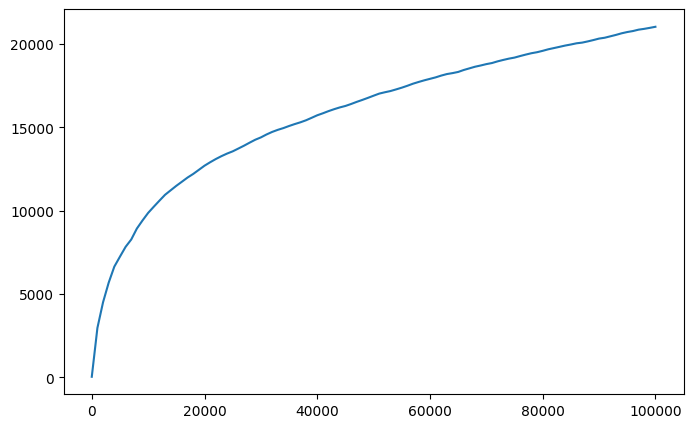

102323it [01:31, 1116.30it/s]


In [15]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

T_s2l = torch.zeros(sonar_t2v.tokenizer.vocab_info.size, lisa_tokenizer.vocab_size)

non_zero_elements = {}

for i, text in tqdm(enumerate(texts)):
    sonar_subwords = get_sonar_subwords(text)
    lisa_subwords = get_lisa_subwords(text)
    
    # alignment = aligner.align(TokenizedSet(tokens=[sonar_subwords, lisa_subwords]))[0]
    alignment = aligner.align(TokenizedSet(tokens=[lisa_subwords, sonar_subwords]))[0]
    pos_alignment = list(alignment)
    subwords_alignment = list(alignment.__tokens__())

    sonar_tokens = get_sonar_ids(sonar_subwords)
    lisa_tokens = get_lisa_ids(lisa_subwords)
    assert len(sonar_tokens) == len(sonar_subwords) and len(lisa_tokens) == len(lisa_subwords)

    for token_from, tokens_to in pos_alignment:
        for token_to in tokens_to:
            # print(sonar_tokens[token_to], lisa_tokens[token_from])
            T_s2l[sonar_tokens[token_to], lisa_tokens[token_from]] += 1
    
    if i % 1000 == 0:
        non_zero_elements[i] = T_s2l.count_nonzero()

    if i % 10000 == 0:
        clear_output()
        plt.figure(figsize=(8, 5))
        plt.plot(non_zero_elements.keys(), non_zero_elements.values())
        plt.show()

In [16]:
T_s2l.count_nonzero()

tensor(21205)

In [212]:
pos_alignment

[(0, [0]), (1, [0, 1]), (2, [2]), (3, [2])]

In [213]:
subwords_alignment

[('▁ch', ['▁chi']),
 ('icken', ['▁chi', 'cken']),
 ('▁sal', ['▁salad']),
 ('ad', ['▁salad'])]

In [214]:
lisa_subwords, sonar_subwords

(['▁ch', 'icken', '▁sal', 'ad'], ['▁chi', 'cken', '▁salad'])

In [17]:
T_s2l_normalized = T_s2l / (T_s2l.sum(dim=1, keepdim=True) + 1e-4)

In [215]:
row_sums = T_s2l.sum(dim=1)
mask = row_sums != 0 

T_s2l_normalized = T_s2l.clone()
T_s2l_normalized[mask] = T_s2l[mask] / row_sums[mask].unsqueeze(1)

In [18]:
T_s2l_normalized.shape

torch.Size([256206, 32000])

In [19]:
T_s2l_normalized.count_nonzero()

tensor(21205)

### checking transformation

In [232]:
text = 'chicken salad'

sonar_subwords = get_sonar_subwords(text)
lisa_subwords = get_lisa_subwords(text)

import spacy_alignments as tokenizations
a2b, _ = tokenizations.get_alignments(lisa_subwords, sonar_subwords)
a2b

[[0], [0, 1], [2], [2]]

In [233]:
print('lisa subwords', lisa_subwords)
print('sonar subwords', sonar_subwords)

lisa subwords ['▁ch', 'icken', '▁sal', 'ad']
sonar subwords ['▁chi', 'cken', '▁salad']


In [234]:
lisa_tokens = get_lisa_ids(lisa_subwords)
sonar_tokens = get_sonar_ids(sonar_subwords)
sonar_probs = torch.nn.functional.one_hot(torch.tensor(sonar_tokens), num_classes=sonar_t2v.tokenizer.vocab_info.size)

sonar_probs.shape

torch.Size([3, 256206])

In [284]:
pre_lisa_probs = torch.zeros(len(lisa_tokens), sonar_probs.shape[1])

for i in range(len(a2b)):
    for j in range(len(a2b[i])):
        pre_lisa_probs[i, :] += sonar_probs[a2b[i][j], :]
    pre_lisa_probs[i, :] /= len(a2b[i])

In [285]:
pre_lisa_probs.sum(1)

tensor([1., 1., 1., 1.])

In [286]:
lisa_probs = pre_lisa_probs @ T_s2l_normalized
lisa_probs += torch.rand(lisa_probs.shape)
lisa_tokenizer.decode(lisa_probs.argmax(-1))

'chickenadad'

In [287]:
sonar_subwords

['▁chi', 'cken', '▁salad']

In [231]:
lisa_subwords

['▁ch', 'icken', '▁sal', 'ad']

In [59]:
lisa_probs[:, 11407]

tensor([0.0007, 0.0010, 0.0382, 0.0382, 0.0008, 0.0002])

In [60]:
lisa_probs[:, 10371]

tensor([1.2626e-04, 8.7774e-04, 4.1689e-01, 2.5035e-01, 6.6277e-04, 2.4264e-04])

##### insert 1 to vectors that coincide

In [288]:
def get_lisa_subword(token_id):
    return lisa_tokenizer.convert_ids_to_tokens(token_id)

def get_sonar_subword(token_id):
    return sonar_t2v.tokenizer.model.index_to_token(token_id)

In [315]:
get_sonar_subword(3)

'</s>'

In [289]:
T_s2l = torch.zeros(sonar_t2v.tokenizer.vocab_info.size, lisa_tokenizer.vocab_size)

In [290]:
sonar_vocab_size = sonar_t2v.tokenizer.vocab_info.size
exact_match = {}

for i in range(sonar_vocab_size):
    subword = get_sonar_subword(i)
    lisa_ids = get_lisa_ids(subword)
    if lisa_ids != 0:
        exact_match[i] = lisa_ids

In [298]:
import torch

key_list = list(exact_match.keys())
tensor_array = torch.tensor(key_list)
torch.save(tensor_array, "matched_sonar_ids.pt")

In [291]:
for sonar_id, lisa_id in exact_match.items():
    T_s2l[sonar_id, :] = 0
    T_s2l[sonar_id, lisa_id] = 1

In [293]:
sparse_matrix = T_s2l.to_sparse()
torch.save(sparse_matrix, "very_sparse_Ts2l.pt")

In [292]:
T_s2l.count_nonzero()

tensor(21037)

#### save matrix

In [20]:
import torch
sparse_matrix = T_s2l_normalized.to_sparse()

In [21]:
torch.save(sparse_matrix, "sparse_Ts2l.pt")

In [45]:
v = torch.rand((1, T_s2l_normalized.shape[0]))
v /= v.sum(1)
v.sum(1)


tensor([1.])

In [47]:
(v @ sparse_matrix).sum()

tensor(0.0938)

In [19]:
exact_match[349]

278

In [84]:
get_sonar_subword(349)

'▁the'

In [85]:
get_lisa_subword(278)

'▁the'

In [86]:
T_s2l_normalized[349, 278]

tensor(1.)

In [ ]:
T_s2l[349, ;]

In [78]:
T_s2l_normalized.shape

torch.Size([256206, 32000])

#### lisa2sonar

In [153]:
T_l2s = torch.zeros(lisa_tokenizer.vocab_size, sonar_t2v.tokenizer.vocab_info.size)
T_l2s.shape

torch.Size([32000, 256206])

In [154]:
from tqdm import tqdm

for text in tqdm(texts):
    sonar_subwords = get_sonar_subwords(text)
    lisa_subwords = get_lisa_subwords(text)
    
    alignment = aligner.align(TokenizedSet(tokens=[lisa_subwords, sonar_subwords]))[0]
    pos_alignment = list(alignment)
    subwords_alignment = list(alignment.__tokens__())

    sonar_tokens = get_sonar_ids(sonar_subwords)
    lisa_tokens = get_lisa_ids(lisa_subwords)
    assert len(sonar_tokens) == len(sonar_subwords) and len(lisa_tokens) == len(lisa_subwords)

    for token_from, tokens_to in pos_alignment:
        for token_to in tokens_to:
            T_l2s[lisa_tokens[token_from], sonar_tokens[token_to]] += 1

100%|██████████| 3408/3408 [00:04<00:00, 710.70it/s]


In [177]:
row_sums = T_l2s.sum(dim=1)
mask = row_sums != 0 

T_l2s_normalized = T_l2s.clone()
T_l2s_normalized[mask] = T_l2s[mask] / row_sums[mask].unsqueeze(1)

## Ablation with Tokenizers

### only from text corpura

In [ ]:
import os
import json

json_dir = "../../dataset/reason_seg/ReasonSeg/test"

texts = []

for filename in os.listdir(json_dir):
    if filename.endswith(".json"):
        file_path = os.path.join(json_dir, filename)
        with open(file_path, 'r') as f:
            data = json.load(f)
            if "text" in data:
                texts.extend(data["text"])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 3408


In [ ]:
directory = '../../dataset/llm-seg40k/validation.json'
text = "In this space that is conducive to learning, what can be used to write on the whiteboard?"

with open(directory, 'r') as f:
    json_file = json.load(f)

for image, infos in json_file.items():
    questions = [info['question'] for info in infos['qa_pairs']]
    for text in questions:
        texts.append(text)

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 7313


In [ ]:
import pickle

directory = '../../dataset/refer_seg/refcocog/refs(google).p'
with open(directory, 'rb') as f:
    data = pickle.load(f)

for item in data:
    for sentence in item['sentences']:
        texts.append(sentence['sent'])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 102323


In [ ]:
from tqdm import tqdm 

valid_sonar_subwords = set()

for text in tqdm(texts):
    tokens = sonar_tokenize(text)
    for t in tokens:
        subword = get_sonar_subword(t)
        valid_sonar_subwords.add(subword)

print(f"Overall Sonar vocab size: {sonar_t2v.tokenizer.vocab_info.size}")
print(f"Found {len(valid_sonar_subwords)} valid tokens")

In [ ]:
from tqdm import tqdm 

valid_bert_subwords = set()

for text in tqdm(texts):
    tokens = bert_tokenizer.encode(text, add_special_tokens=False)
    for t in tokens:
        subword = bert_tokenizer.decode([t])
        valid_bert_subwords.add(subword)

print(f"Overall BERT vocab size: {bert_tokenizer.vocab_size}")
print(f"Found {len(valid_bert_subwords)} valid tokens")

In [ ]:
from tqdm import tqdm 

valid_lisa_subwords = set()

for text in tqdm(texts):
    tokens = lisa_tokenizer.encode(text, add_special_tokens=False)
    for t in tokens:
        subword = lisa_tokenizer.convert_ids_to_tokens(t) 
        valid_lisa_subwords.add(subword)

print(f"Overall LISA vocab size: {lisa_tokenizer.vocab_size}")
print(f"Found {len(valid_lisa_subwords)} valid tokens")

### from all tokens in the vocab

In [193]:
import torch

from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)
        
sonar_v2t = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)

In [194]:
def get_sonar_subword(token_id):
    return sonar_t2v.tokenizer.model.index_to_token(token_id)

def sonar_tokenize(text):
    return sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(text)[1:-1].tolist()

In [195]:
def is_valid_token(subword):
    return all((c.isascii() and c.isalpha()) for c in subword)

valid_sonar_token_ids = {}
for i in range(sonar_t2v.tokenizer.vocab_info.size):
    subword = get_sonar_subword(i)
    if is_valid_token(subword.replace("▁", "")):
        valid_sonar_token_ids[i] = subword

print(f"Overall Sonar vocab size: {sonar_t2v.tokenizer.vocab_info.size}")
print(f"Found {len(valid_sonar_token_ids)} valid tokens")

Overall Sonar vocab size: 256206
Found 108091 valid tokens


### BERT tokenizer

In [171]:
from transformers import BertTokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [172]:
bert_tokenizer.encode('reorganize', add_special_tokens=False)

[2128, 21759, 7088, 4371]

In [173]:
[bert_tokenizer.decode([i]) for i in bert_tokenizer.encode('reorganize', add_special_tokens=False)]

['re', '##org', '##ani', '##ze']

In [176]:
def is_valid_token(subword):
    return all((c.isascii() and c.isalpha()) or c == "▁" for c in subword)

valid_bert_subwords = set()
for i in range(bert_tokenizer.vocab_size):
    subword = bert_tokenizer.decode([i]).replace("##", "▁")
    if is_valid_token(subword):
        valid_bert_subwords.add(subword)

print(f"Overall BERT vocab size: {bert_tokenizer.vocab_size}")
print(f"Found {len(valid_bert_subwords)} valid tokens")

Overall BERT vocab size: 30522
Found 26503 valid tokens


In [177]:
mached_tokens = 0

for subword in valid_bert_subwords:
    if subword in valid_sonar_subwords:
        mached_tokens += 1

print(f"Found {mached_tokens} matched tokens")

Found 1033 matched tokens


In [178]:
print(f"Percentage of matched tokens: {mached_tokens / len(valid_bert_subwords) * 100:.0f}%")

Percentage of matched tokens: 4%


### LISA tokenizer

In [197]:
from transformers import AutoTokenizer

lisa_tokenizer = AutoTokenizer.from_pretrained(
    "xinlai/LISA-13B-llama2-v1",
    use_fast=False,
    add_eos_token=True
)
lisa_tokenizer.pad_token = lisa_tokenizer.unk_token

/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [198]:
lisa_tokenizer.encode('reorganize', add_special_tokens=False)

[337, 6388, 675]

In [199]:
[lisa_tokenizer.decode([i]) for i in lisa_tokenizer.encode('reorganize', add_special_tokens=False)]

['re', 'organ', 'ize']

In [200]:
def is_valid_token(subword):
    return all((c.isascii() and c.isalpha()) or c == "▁" for c in subword)

valid_lisa_subwords = set()
for subword, id in lisa_tokenizer.get_vocab().items():
    if is_valid_token(subword):
        valid_lisa_subwords.add(subword)

print(f"Overall LISA vocab size: {lisa_tokenizer.vocab_size}")
print(f"Found {len(valid_lisa_subwords)} valid tokens")

Overall LISA vocab size: 32000
Found 24084 valid tokens


In [202]:
mached_tokens = 0

for subword in valid_lisa_subwords:
    if subword in valid_sonar_subwords:
        mached_tokens += 1

print(f"Found {mached_tokens} matched tokens")

Found 3033 matched tokens


In [203]:
print(f"Percentage of matched tokens: {mached_tokens / len(valid_lisa_subwords) * 100:.0f}%")

Percentage of matched tokens: 13%


### GPT tokenizer

In [ ]:
from transformers import GPT2Tokenizer
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

In [ ]:

# 3. RoBERTa-base (byte-level BPE)
from transformers import RobertaTokenizer
# loads byte-level BPE trained on a large CommonCrawl+News+BookCorpus corpus (~50k vocab)
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# 4. T5-base (SentencePiece Unigram)
from transformers import T5Tokenizer
# loads a SentencePiece tokenizer (unigram LM) trained on C4 dataset (~32k vocab)
t5_tokenizer = T5Tokenizer.from_pretrained('t5-base')

# 5. LLaMA-7B (byte-level BPE)
from transformers import LlamaTokenizer
# loads LLaMA's byte-level BPE tokenizer trained on a massive multilingual CommonCrawl corpus (~32k vocab)
llama_tokenizer = LlamaTokenizer.from_pretrained('meta-llama/Llama-2-7b')